# 06 - Content Analytics KPI Dashboard

## Digikala Content Analytics Project


## Business Context

In e-commerce platforms, content quality has a direct impact
on customer experience and business performance.

Content Analytics teams analyze:

- Product information quality
- Customer satisfaction
- Category performance
- Improvement opportunities


The goal of this notebook is to transform raw product
and customer feedback data into actionable business insights.



## Objectives

This notebook will:

- Integrate product and review datasets
- Create content quality metrics
- Measure customer satisfaction
- Analyze category performance
- Identify content improvement opportunities
- Generate business recommendations



## Business Questions

1. Which product categories have content quality issues?

2. Which products require content optimization?

3. Is better content quality associated with higher satisfaction?

4. Where should content teams focus their efforts?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")


pd.set_option(
    "display.max_columns",
    None
)


print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
products = pd.read_csv(
    "../data/processed/products_clean.csv"
)


products.head()

,id,title_fa,Rate,Rate_cnt,Category1,Category2,Brand,Price,Seller,Is_Fake,min_price_last_month,sub_category
0,7096438,آبسلانگ مدل s5 بسته 250 عددی,90,4,آبسلانگ,NaN,متفرقه,634800,سلامت ساز راد,False,0,beauty
1,2845119,آبسلانگ مدل M-1 بسته 400 عددی,84,217,آبسلانگ,NaN,متفرقه,818800,مهر افزون,False,0,beauty
2,6117745,آبسلانگ مدل m50 مجموعه 500 عددی,88,14,آبسلانگ,NaN,متفرقه,920000,یانگوم,False,0,beauty
3,1912926,استند ابسلانگ مدل S01,78,25,آبسلانگ,NaN,متفرقه,1100000,بهراد طب بیدار,False,0,beauty
4,6335462,آبسلانگ نوری تسلامد مدل All-in-One,84,25,آبسلانگ,NaN,تسلا مد,1530000,دیجی‌کالا,False,0,beauty


In [3]:
comments = pd.read_csv(
    "../data/processed/comments_clean.csv"
)


comments.head()

,id,title,body,created_at,rate,recommendation_status,is_buyer,product_id,advantages,disadvantages,likes,dislikes,seller_title,seller_code,true_to_size_rate
0,53672599,پیشنهاد نمیشود,به درد نمیخوره,23 شهریور 1402,1.0,not_recommended,True,252058,NaN,NaN,0,0,دیجی‌کالا,5A52N,NaN
1,9897229,بسته بندی بد,می‌تونست به عنوان یه کالای فرهنگی بهتر بسته بن...,16 تیر 1399,0.0,recommended,True,252058,['تجربه جالبی بود برام '],['بسته بندی جالبی نداشت'],1,0,دیجی‌کالا,5A52N,NaN
2,38074516,برس ریمل,بسته بندیش خوب بود\r\n کاربرد و کیفیتشم خیلی خ...,26 مرداد 1401,0.0,recommended,True,3331597,NaN,NaN,0,0,آرالیا بیوتی,ADM47,NaN
3,18628562,خوبه و خوشرنگ,به نظرم خوبه فقط یکم ظریفه. از رنگش خوشم اومد ...,28 اسفند 1399,0.0,recommended,True,3331329,NaN,NaN,0,0,اینجاست آ,9ZMCZ,NaN
4,53301258,برس رنگ مو,معمولیه اگه واسه خونه رنگ کردن شخصی میخواین او...,12 شهریور 1402,3.0,recommended,True,3255700,NaN,NaN,0,0,گالری آرایشی به سیما,CDWHA,NaN


In [4]:
print(products.shape)

print(comments.shape)

(960367, 12)
(199997, 15)


In [5]:
print(products.columns.tolist())

print(comments.columns.tolist())

['id', 'title_fa', 'Rate', 'Rate_cnt', 'Category1', 'Category2', 'Brand', 'Price', 'Seller', 'Is_Fake', 'min_price_last_month', 'sub_category']
['id', 'title', 'body', 'created_at', 'rate', 'recommendation_status', 'is_buyer', 'product_id', 'advantages', 'disadvantages', 'likes', 'dislikes', 'seller_title', 'seller_code', 'true_to_size_rate']


In [6]:
products = products.rename(
    columns={
        "id":"product_id"
    }
)

In [7]:
products[
    [
        "product_id",
        "title_fa"
    ]
].head()

,product_id,title_fa
0,7096438,آبسلانگ مدل s5 بسته 250 عددی
1,2845119,آبسلانگ مدل M-1 بسته 400 عددی
2,6117745,آبسلانگ مدل m50 مجموعه 500 عددی
3,1912926,استند ابسلانگ مدل S01
4,6335462,آبسلانگ نوری تسلامد مدل All-in-One


In [8]:
data = comments.merge(

    products,

    on="product_id",

    how="left"

)


data.head()

,id,title,body,created_at,rate,recommendation_status,is_buyer,product_id,advantages,disadvantages,likes,dislikes,seller_title,seller_code,true_to_size_rate,title_fa,Rate,Rate_cnt,Category1,Category2,Brand,Price,Seller,Is_Fake,min_price_last_month,sub_category
0,53672599,پیشنهاد نمیشود,به درد نمیخوره,23 شهریور 1402,1.0,not_recommended,True,252058,NaN,NaN,0,0,دیجی‌کالا,5A52N,NaN,کتاب صوتی امپراطوری اپ اثر چاد مورتا,74,212,کتاب صوتی,NaN,نوین کتاب گویا,199000,دیجی‌کالا,False,0,book & stationary & art
1,9897229,بسته بندی بد,می‌تونست به عنوان یه کالای فرهنگی بهتر بسته بن...,16 تیر 1399,0.0,recommended,True,252058,['تجربه جالبی بود برام '],['بسته بندی جالبی نداشت'],1,0,دیجی‌کالا,5A52N,NaN,کتاب صوتی امپراطوری اپ اثر چاد مورتا,74,212,کتاب صوتی,NaN,نوین کتاب گویا,199000,دیجی‌کالا,False,0,book & stationary & art
2,38074516,برس ریمل,بسته بندیش خوب بود\r\n کاربرد و کیفیتشم خیلی خ...,26 مرداد 1401,0.0,recommended,True,3331597,NaN,NaN,0,0,آرالیا بیوتی,ADM47,NaN,برس ریمل مدل LM02 مجموعه 2 عددی,84,587,برس‌ها و تجهیزات آرایشی,برس ها و تجهیزات آرایشی چشم و ابرو,متفرقه,79000,پینک لندشاپ,False,0,beauty
3,18628562,خوبه و خوشرنگ,به نظرم خوبه فقط یکم ظریفه. از رنگش خوشم اومد ...,28 اسفند 1399,0.0,recommended,True,3331329,NaN,NaN,0,0,اینجاست آ,9ZMCZ,NaN,برس ریمل مدل MNP-03,82,465,برس‌ها و تجهیزات آرایشی,برس ها و تجهیزات آرایشی چشم و ابرو,متفرقه,80000,یانگوم,False,0,beauty
4,53301258,برس رنگ مو,معمولیه اگه واسه خونه رنگ کردن شخصی میخواین او...,12 شهریور 1402,3.0,recommended,True,3255700,NaN,NaN,0,0,گالری آرایشی به سیما,CDWHA,NaN,برس رنگ مو مدل 01,82,19,برس‌ها و تجهیزات آرایشی,تجهیزات رنگ مو,متفرقه,84100,گالری آرایشی به سیما,False,84100,beauty


In [9]:
data.shape

(247297, 26)

In [10]:
data.columns.tolist()

['id',
 'title',
 'body',
 'created_at',
 'rate',
 'recommendation_status',
 'is_buyer',
 'product_id',
 'advantages',
 'disadvantages',
 'likes',
 'dislikes',
 'seller_title',
 'seller_code',
 'true_to_size_rate',
 'title_fa',
 'Rate',
 'Rate_cnt',
 'Category1',
 'Category2',
 'Brand',
 'Price',
 'Seller',
 'Is_Fake',
 'min_price_last_month',
 'sub_category']

In [11]:
content_features = [

"title_fa",

"Category1",

"Brand",

"Seller",

"Price"

]

In [12]:
data["Content_Completeness"] = (

    data[content_features]

    .notnull()

    .mean(axis=1)

)


data[
"Content_Completeness"
].describe()

count    247297.000000
mean          0.999959
std           0.002872
min           0.800000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: Content_Completeness, dtype: float64

In [13]:
data["Recommendation_Score"] = (

    data["recommendation_status"]

    .astype(str)

    .str.lower()

    .str.contains(
        "recommend"
    )

    .astype(int)

)

In [14]:
data["Customer_Satisfaction"] = (

    0.5 *
    (data["rate"]/5)

    +

    0.5 *
    data["Recommendation_Score"]

)


data[
"Customer_Satisfaction"
].describe()

count    247297.000000
mean          0.749094
std           0.267020
min           0.000000
25%           0.500000
50%           0.900000
75%           1.000000
max           1.000000
Name: Customer_Satisfaction, dtype: float64

In [15]:
data["Engagement_Score"] = (

    data["likes"]

    /

    data["likes"].max()

)


data[
"Engagement_Score"
].describe()

count    247297.000000
mean          0.001447
std           0.007156
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: Engagement_Score, dtype: float64

In [16]:
data["Opportunity_Score"] = (

    (1-data["Content_Completeness"])

    *

    (1-data["Customer_Satisfaction"])

)

In [17]:
priority_products = (

    data.sort_values(

        "Opportunity_Score",

        ascending=False

    )

    [
        [
        "title_fa",
        "Category1",
        "Brand",
        "Price",
        "rate",
        "Opportunity_Score"
        ]
    ]

)


priority_products.head(20)

,title_fa,Category1,Brand,Price,rate,Opportunity_Score
199550,دهان شویه یروکس کد 0432001 حجم 250 میلی لیتر م...,بهداشت دهان و دندان,ایروکس,0,1.0,0.18
199584,دهان شویه یروکس کد 0432001 حجم 250 میلی لیتر م...,بهداشت دهان و دندان,ایروکس,0,2.0,0.16
34038,آب پاک کننده آرایش صورت گارنیه مدل met rozenwa...,مراقبت پوست,گارنیه,0,4.0,0.12
199570,دهان شویه یروکس کد 0432001 حجم 250 میلی لیتر م...,بهداشت دهان و دندان,ایروکس,0,4.0,0.12
155388,شامپو مو کاندید مدل Purifying حجم 200 میلی لیتر,شامپو و مراقبت مو,کاندید,0,4.0,0.12
155384,شامپو مو کاندید مدل Purifying حجم 200 میلی لیتر,شامپو و مراقبت مو,کاندید,0,4.0,0.12
128471,شامپو مو کاندید مدل Purifying حجم 200 میلی لیتر,شامپو و مراقبت مو,کاندید,0,4.0,0.12
199578,دهان شویه یروکس کد 0432001 حجم 250 میلی لیتر م...,بهداشت دهان و دندان,ایروکس,0,0.0,0.10
199574,دهان شویه یروکس کد 0432001 حجم 250 میلی لیتر م...,بهداشت دهان و دندان,ایروکس,0,0.0,0.10
34041,آب پاک کننده آرایش صورت گارنیه مدل met rozenwa...,مراقبت پوست,گارنیه,0,0.0,0.10


In [18]:
category_analysis = (

    data
    .groupby("Category1")
    .agg(

        products=
        ("product_id","nunique"),


        reviews=
        ("product_id","count"),


        avg_content_quality=
        ("Content_Completeness","mean"),


        avg_customer_satisfaction=
        ("Customer_Satisfaction","mean"),


        avg_rating=
        ("rate","mean"),


        avg_engagement=
        ("Engagement_Score","mean")

    )

    .sort_values(

        "avg_content_quality",

        ascending=True

    )

)


category_analysis.head(10)

,products,reviews,avg_content_quality,avg_customer_satisfaction,avg_rating,avg_engagement
Category1,,,,,,
بهداشت دهان و دندان,416,7425,0.999273,0.762701,3.695697,0.000946
ضد تعریق,186,4217,0.999715,0.780775,3.758667,0.000628
شامپو و مراقبت مو,790,19968,0.999940,0.751817,3.883351,0.001121
بهداشت و مراقبت بدن,471,11726,0.999949,0.786035,3.983494,0.000990
مراقبت پوست,1284,52346,0.999966,0.761714,3.946656,0.001391
موسیقی بی‌کلام,28,54,1.000000,0.785000,4.331481,0.001377
موسیقی با کلام,42,204,1.000000,0.791127,4.014216,0.002314
مستند,7,26,1.000000,0.775000,3.519231,0.003146
مراقبت کودکان,1,10,1.000000,0.720000,4.200000,0.005204


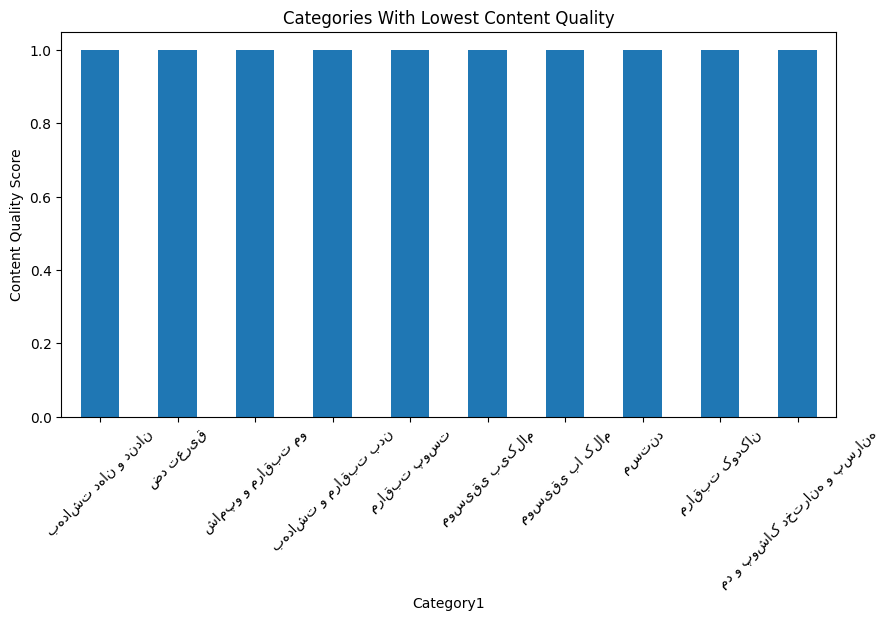

In [19]:
category_analysis.head(10)[

"avg_content_quality"

].plot(

kind="bar",

figsize=(10,5)

)


plt.title(
"Categories With Lowest Content Quality"
)


plt.ylabel(
"Content Quality Score"
)


plt.xticks(rotation=45)

plt.show()

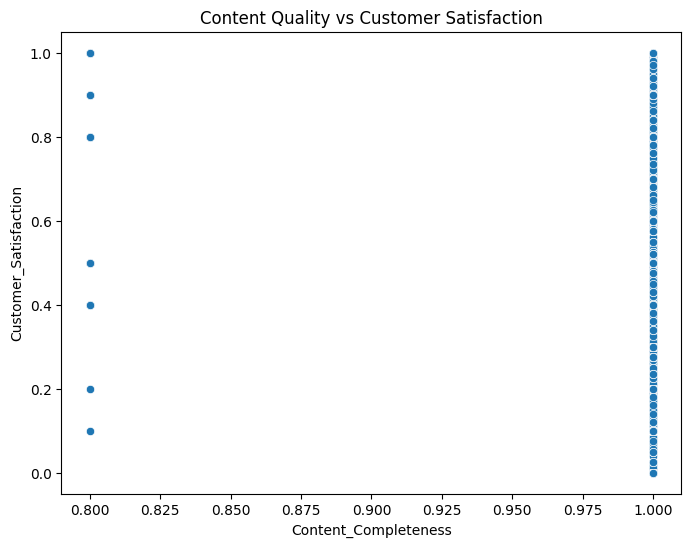

In [20]:
plt.figure(figsize=(8,6))


sns.scatterplot(

data=data,

x="Content_Completeness",

y="Customer_Satisfaction"

)


plt.title(
"Content Quality vs Customer Satisfaction"
)


plt.show()

# Business Insights


## Content Team

Products with low content completeness
should be prioritized for enrichment.


## Customer Experience

Customer feedback reveals:

- Missing information
- Product expectation gaps
- Quality problems


## AI Opportunities

Future automation:


- AI content quality scoring

- Missing attribute detection

- Automatic product description improvement

- Content recommendation engine


# Export Analytics Dataset

The processed analytics dataset will be exported
for AI modeling and automation tasks.

In [21]:
import os

os.makedirs(
    "../data/processed",
    exist_ok=True
)


data.to_csv(

    "../data/processed/content_analytics_dataset.csv",

    index=False,

    encoding="utf-8-sig"

)


print(
    "Analytics dataset exported successfully"
)

Analytics dataset exported successfully


# Summary


Completed:


✔ Product-review integration

✔ Content Quality KPI

✔ Customer Satisfaction KPI

✔ Engagement Metrics

✔ Opportunity Scoring

✔ Category Analytics

✔ Business Recommendations



Next Notebook:

07_AI_Content_Optimization_System
